In [185]:
import numpy as np
import sympy as sp
import control as ct
import matplotlib.pyplot as plt
import scipy.signal
import scipy.linalg
import cvxpy as cp

In [186]:
x, v, theta, omega = sp.symbols('x  v theta omega') # States
m, M, L, g, delta, u = sp.symbols('m M L g delta u') # Physical Parameters

f = sp.Matrix([
    v,
    (-m**2*L**2*g*sp.cos(theta)*sp.sin(theta)
     + m*L**2*(m*L*omega**2*sp.sin(theta) - delta*v)
     + m*L**2*u) / (m*L**2*(M + m*(1 - sp.cos(theta)**2))),
    omega,
    ((m+M)*m*g*L*sp.sin(theta)
     - m*L*sp.cos(theta)*(m*L*omega**2*sp.sin(theta) - delta*v)
     - m*L*sp.cos(theta)*u) / (m*L**2*(M + m*(1 - sp.cos(theta)**2)))
])

x_vec = sp.Matrix([x, v, theta, omega])
u_vec = sp.Matrix([u])

A_sym = f.jacobian(x_vec)
B_sym = f.jacobian(u_vec)

params = {m : 1, M : 5, L : 2, g : -10, delta : 1}
A_params = A_sym.subs(params)
B_params = B_sym.subs(params)

eq1 = {x : 0, v : 0, theta : 0, omega : 0}
eq2 = {x: 0, v : 0, theta : sp.pi, omega : 0}

A_eq1 = A_params.subs(eq1)
B_eq1 = B_params.subs(eq1)

A_eq2 = A_params.subs(eq2)
B_eq2 = B_params.subs(eq2)

sp.init_printing()
#display(A_eq1)
#display(B_eq1)
display(A_eq2)
display(B_eq2)

f_lam = sp.lambdify((x, v, theta, omega, u), f.subs(params), 'numpy')
def f_nl(s, uu):
    return np.asarray(f_lam(*s, float(np.ravel(uu)[0])), dtype=float).ravel()


⎡0    1    0  0⎤
⎢              ⎥
⎢0  -1/5   2  0⎥
⎢              ⎥
⎢0    0    0  1⎥
⎢              ⎥
⎣0  -1/10  6  0⎦

⎡ 0  ⎤
⎢    ⎥
⎢1/5 ⎥
⎢    ⎥
⎢ 0  ⎥
⎢    ⎥
⎣1/10⎦

In [187]:
A1 = np.array(A_eq1).astype(np.float64)
B1 = np.array(B_eq1).astype(np.float64)
A2 = np.array(A_eq2).astype(np.float64)
B2 = np.array(B_eq2).astype(np.float64)

print('Matrix rank is', np.linalg.matrix_rank(ct.ctrb(A1,B1)))
print('Matrix rank is', np.linalg.matrix_rank(ct.ctrb(A2,B2)))

Matrix rank is 4
Matrix rank is 4


In [188]:
A = A2
B = B2

dt = 0.1

sys = scipy.signal.StateSpace(A,B, np.eye(4), np.zeros((4,1)))
sysd = sys.to_discrete(dt)

Ad = sysd.A
Bd = sysd.B
Cd = sysd.C
Dd = sysd.D

T = 100
n = 4
nu = 1
MPC = 10

Q = np.diag([1, 1, 1, 1])
R = np.array([[0.01]])
u_max = 60.0

K, P, E = ct.dlqr(Ad, Bd, Q, R)

initial_state = np.array([0.0, 0.0, np.pi,0.0])
state = initial_state.copy()
goal_state = np.array([1.0, 0.0, np.pi, 0.0])

assert np.allclose(f_nl(goal_state, 0.0), 0.0, atol=1e-12)

states = np.zeros((T+1, n))
controls = np.zeros((T, nu))
states[0] = state

In [189]:
for k in range(T):

    xs = cp.Variable((MPC+1, n))
    us = cp.Variable((MPC, nu))

    objective = 0
    constraints = [xs[0] == state - goal_state]

    for t in range(MPC):
        objective += (cp.quad_form(xs[t], Q) + cp.quad_form(us[t],R))
        constraints += [xs[t+1] == Ad @ xs[t] + Bd @ us[t]]
        constraints += [cp.abs(us[t]) <= u_max]

    objective += cp.quad_form(xs[MPC], P)

    problem = cp.Problem(cp.Minimize(objective), constraints)
    problem.solve()

    u_k = us.value[0]
    controls[k] = u_k

    state = goal_state + Ad @ (state - goal_state) + Bd @ u_k 
    states[k+1] = state

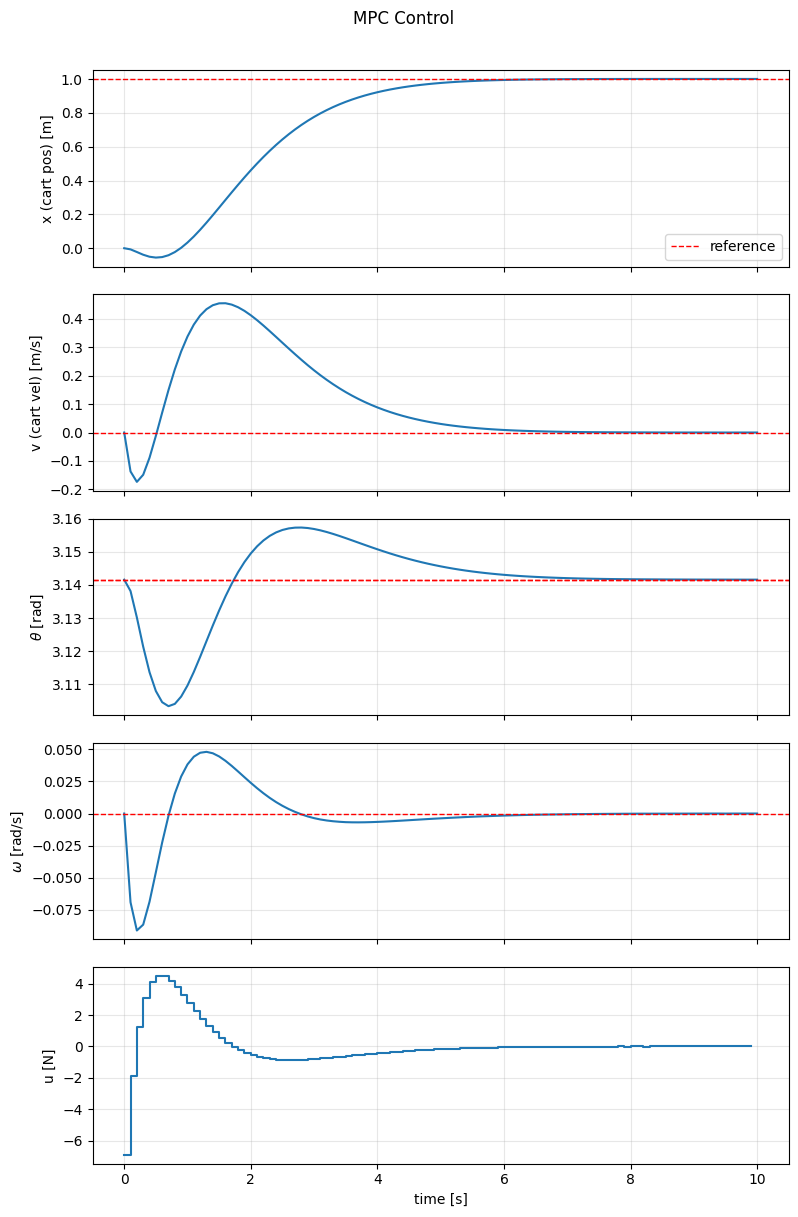

In [190]:
x_hist = states.copy()
u_hist = controls.copy()
t_hist = np.arange(0, T*dt + dt, dt)

fig, axs = plt.subplots(5, 1, figsize=(8, 12), sharex=True)
labels = ['x (cart pos) [m]', 'v (cart vel) [m/s]', r'$\theta$ [rad]', r'$\omega$ [rad/s]']

for i in range(4):
    axs[i].plot(t_hist, x_hist[:, i])
    axs[i].axhline(goal_state[i], color='r', ls='--', lw=1, label='reference')
    axs[i].set_ylabel(labels[i])
    axs[i].grid(alpha=0.3)
axs[2].axhline(np.pi, color='r', ls='--', lw=1)   # reference already correct, kept explicit for clarity

axs[4].step(t_hist[:-1], u_hist, where='post')
axs[4].set_ylabel('u [N]')
axs[4].set_xlabel('time [s]')
axs[4].grid(alpha=0.3)

axs[0].legend(loc='lower right')
plt.suptitle('MPC Control', y=1.01)
plt.tight_layout()
plt.show()
